Task 1: Problem Identification  
**Image Classification** is the most appropriate problem type for the given dataset. The dataset consists of images belonging to one of four groups (normal, scratch, dent and stain). The goal is to assign a single categorical label to images (image classification) and not identifying objects with bounding boxes (object detection) or marking specific boundary pixels (image segmentaion).

In [1]:
import os
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras import layers, models, Input
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# Task 2: Dataset Exploration
# Setting the path of the dataset
data_dir = '../ai_project_synthetic_datasets/part_2_cnn_computer_vision/images'
classes = ['normal', 'scratch', 'dent', 'stain']

# Analysing the images folders from the storage
data_stats = []

for cls in classes:
    folder_path = os.path.join(data_dir, cls)
    images = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    if images:
        sample_img = Image.open(os.path.join(folder_path, images[0]))
        width, height = sample_img.size
    
    data_stats.append({
        'Class': cls,
        'Count': len(images),
        'Dimensions': f"{width}x{height}" if images else "N/A"
    })

df = pd.DataFrame(data_stats)
print(df)

     Class  Count Dimensions
0   normal    120      96x96
1  scratch    120      96x96
2     dent    120      96x96
3    stain    120      96x96


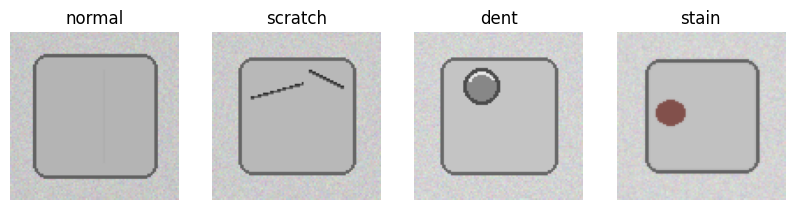

In [3]:
# to show sample images from the dataset
plt.figure(figsize=(10, 5))
for i, cls in enumerate(classes):
    folder_path = os.path.join(data_dir, cls)
    img_name = [f for f in os.listdir(folder_path)][0]
    img = Image.open(os.path.join(folder_path, img_name))
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.show()

In [4]:
# Task 3: Image Preprocessing
# Configuration
IMG_SIZE = (96, 96)
BATCH_SIZE = 32
DATA_PATH = '../ai_project_synthetic_datasets/part_2_cnn_computer_vision/images'

# Training and Validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
my_class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  #layers.RandomRotation(0.1),
])

# Normalising
def preprocess(image, label, augment=False):
    # Rescale pixels to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    if augment:
        image = data_augmentation(image)
    return image, label

# Applying the preprocessing to the datasets
train_ds = train_ds.map(lambda x, y: preprocess(x, y, augment=True))
val_ds = val_ds.map(lambda x, y: preprocess(x, y, augment=False))

# to optimize for performance
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 480 files belonging to 4 classes.
Using 384 files for training.
Found 480 files belonging to 4 classes.
Using 96 files for validation.


In [8]:
# Task 4: CNN Model Creation
model = models.Sequential(name="Manufacturing_Defect_Detector")

model.add(Input(shape=(96, 96, 3)))

# Block 1: Detects basic edges
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2: Detects complex shapes
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3: Detects textures
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

# Smaller Dense layer (more efficient)
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.2370 - loss: 1.4557 - val_accuracy: 0.2292 - val_loss: 1.3916
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.2682 - loss: 1.3845 - val_accuracy: 0.2292 - val_loss: 1.3796
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.3281 - loss: 1.3677 - val_accuracy: 0.4688 - val_loss: 1.3326
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.4792 - loss: 1.2308 - val_accuracy: 0.4896 - val_loss: 1.0607
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.5729 - loss: 1.0059 - val_accuracy: 0.6771 - val_loss: 0.8931
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.7266 - loss: 0.7517 - val_accuracy: 0.7083 - val_loss: 0.6633
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.7760 - loss: 0.5859 - val_accuracy: 0.7917 - val_loss: 0.5481
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.8099 - loss: 0.4598 - val_accuracy: 0.

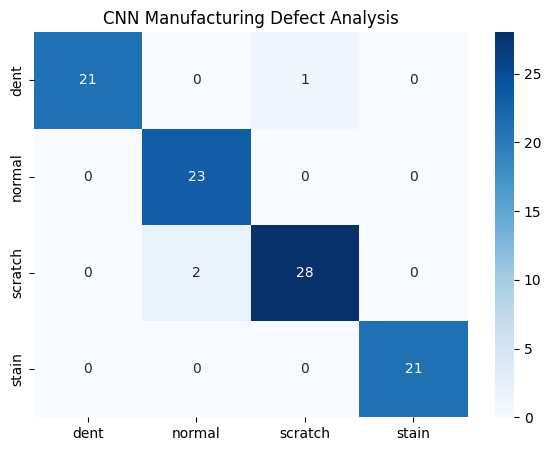

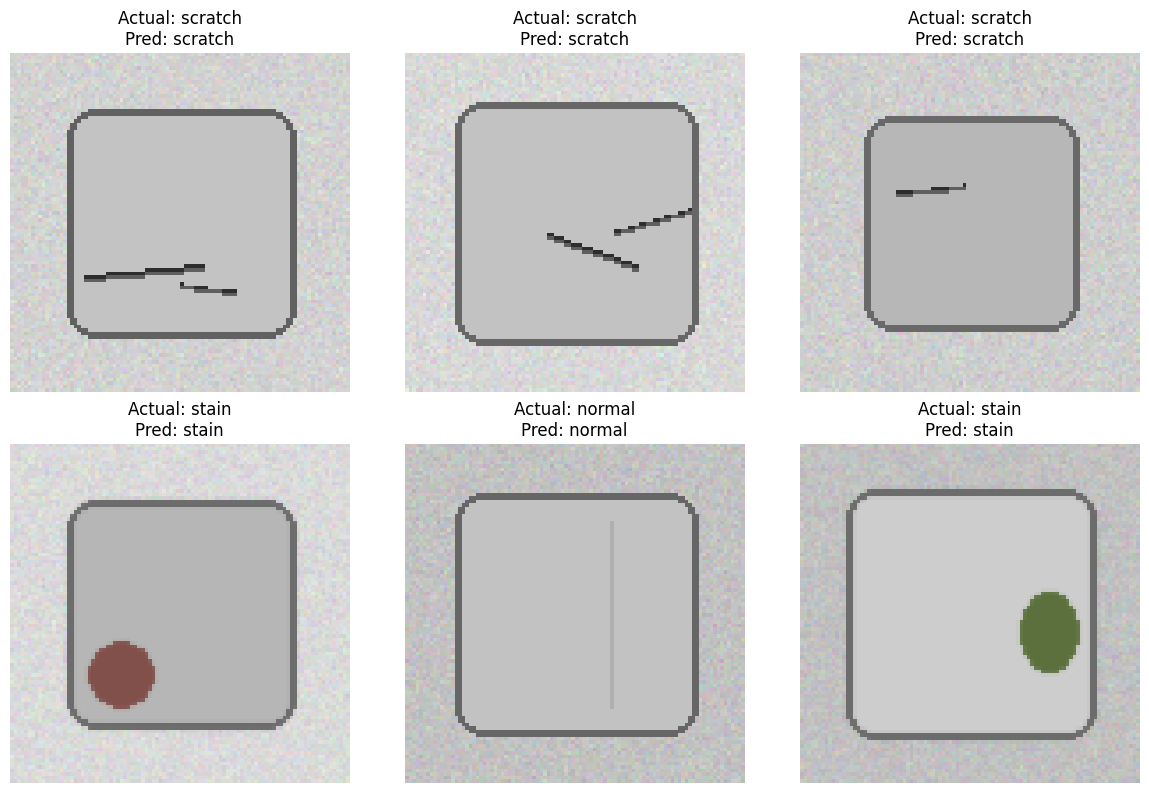

In [ ]:
# Task 5: Model Training and Evaluation
# Training
history = model.fit(train_ds, validation_data=val_ds, epochs=30)

# Accuracy/Loss
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nFinal Training Accuracy: {final_train_acc:.4f}, Loss: {final_train_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}, Loss: {final_val_loss:.4f}")

# Evaluation
all_labels = []
all_preds = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(np.argmax(preds, axis=1))

print("\nDetailed Classification Report:\n", 
      classification_report(all_labels, all_preds, target_names=my_class_names))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=my_class_names, 
            yticklabels=my_class_names)
plt.title('CNN Manufacturing Defect Analysis')
plt.show()

# Sample Predictions
plt.figure(figsize=(12, 8))
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        
        actual_cls = my_class_names[labels[i]]
        pred_cls = my_class_names[np.argmax(preds[i])]
        
        plt.title(f"Actual: {actual_cls}\nPred: {pred_cls}")
        plt.axis("off")
plt.tight_layout()
plt.show()

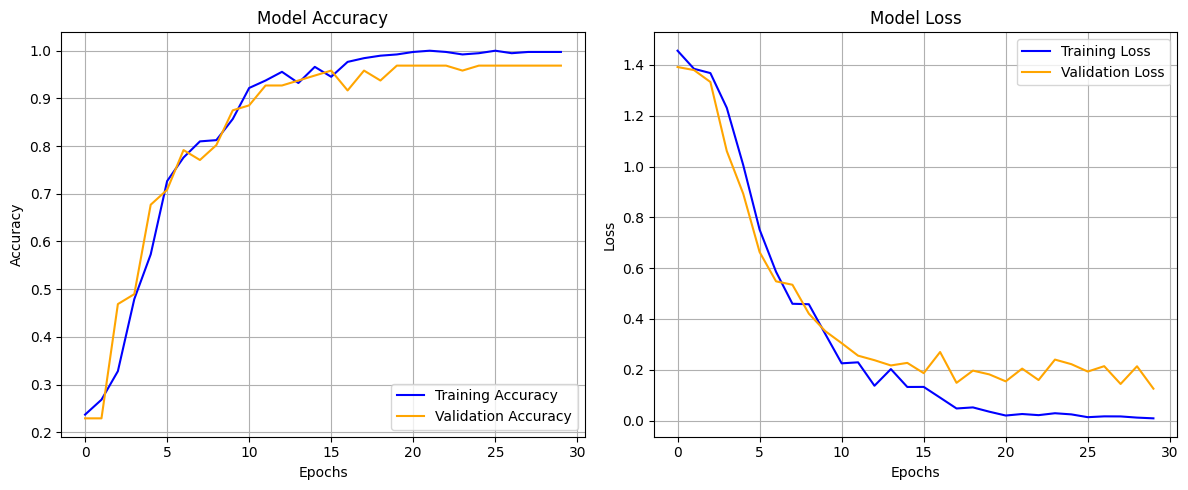

In [10]:
# Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()